<a href="https://colab.research.google.com/github/fajarrinaldi88/Data-Science-2026/blob/main/Pertemuan12_FajarRinaldi_250401020204.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* Nama : Fajar Rinaldi
* NIM : 250401020204
* Kelas : IF405


```
#Pertemuan 12:
```
**Pertemuan 12: Asosiasi Data & Sistem Rekomendasi Dasar**

Algoritma Apriori (Market Basket Analysis) dan konsep Collaborative/Content-Based Filtering.

#### **Library yang Diperlukan**
Perbaikan DeprecationWarning

In [15]:
import datetime as _dt
import jupyter_client.session as _session

class _PatchedDateTime(_dt.datetime):
    @classmethod
    def utcnow(cls):
        return _dt.datetime.now(_dt.timezone.utc)

_session.datetime = _PatchedDateTime

import warnings
warnings.filterwarnings('ignore')
!pip install mlxtend -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.metrics.pairwise import cosine_similarity

# Konfigurasi display
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Library berhasil dimuat")

Library berhasil dimuat


**Generate & Eksplorasi Dataset Transaksi**

In [16]:
# Set seed untuk reproducibility
np.random.seed(42)

# Daftar 10 produk
produk = ['Roti', 'Selai', 'Susu', 'Sereal', 'Telur',
          'Keju', 'Kopi', 'Gula', 'Teh', 'Mentega']

print(f"Daftar Produk ({len(produk)} item):")
for i, p in enumerate(produk, 1):
    print(f"  {i:2d}. {p}")

# Buat 50 transaksi, tiap transaksi berisi 2-5 produk
transaksi = []
for _ in range(50):
    n_item = np.random.randint(2, 6)
    transaksi.append(list(np.random.choice(produk, n_item, replace=False)))

# Suntikkan pola bisnis: Roti sering bersama Selai (20 transaksi pertama)
for i in range(0, 20):
    if 'Roti' in transaksi[i] and 'Selai' not in transaksi[i]:
        transaksi[i].append('Selai')

print(f"\nDibuat {len(transaksi)} transaksi")
print(f"\nContoh 5 transaksi pertama:")
for i, t in enumerate(transaksi[:5], 1):
    print(f"  Transaksi {i}: {t}")

Daftar Produk (10 item):
   1. Roti
   2. Selai
   3. Susu
   4. Sereal
   5. Telur
   6. Keju
   7. Kopi
   8. Gula
   9. Teh
  10. Mentega

Dibuat 50 transaksi

Contoh 5 transaksi pertama:
  Transaksi 1: [np.str_('Keju'), np.str_('Roti'), np.str_('Mentega'), np.str_('Kopi'), 'Selai']
  Transaksi 2: [np.str_('Roti'), np.str_('Kopi'), np.str_('Teh'), np.str_('Selai'), np.str_('Mentega')]
  Transaksi 3: [np.str_('Kopi'), np.str_('Susu'), np.str_('Teh')]
  Transaksi 4: [np.str_('Selai'), np.str_('Keju'), np.str_('Telur'), np.str_('Teh')]
  Transaksi 5: [np.str_('Mentega'), np.str_('Susu'), np.str_('Gula'), np.str_('Keju')]


**Eksplorasi: Frekuensi Produk Individual**

Frekuensi Produk Individual:
 Produk  Frekuensi  Support
  Selai         26     0.52
    Teh         23     0.46
Mentega         21     0.42
  Telur         18     0.36
   Keju         17     0.34
   Roti         16     0.32
   Kopi         16     0.32
   Susu         16     0.32
   Gula         16     0.32
 Sereal          9     0.18


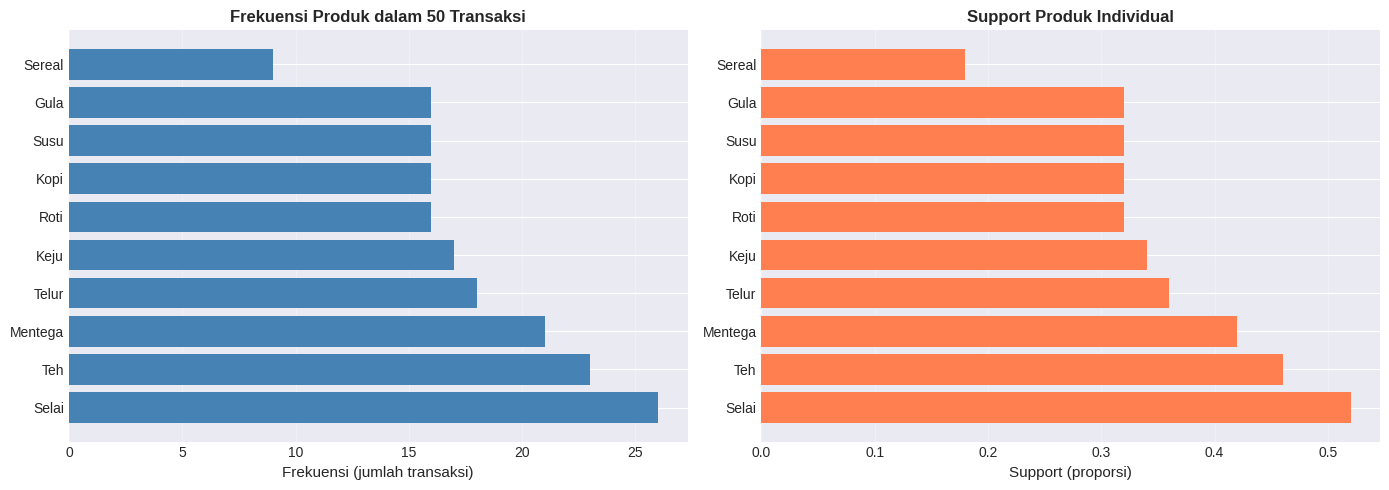


Insight: Produk paling populer adalah Selai (52.0% support)


In [17]:
# Hitung frekuensi tiap produk
produk_count = {}
for t in transaksi:
    for item in t:
        produk_count[item] = produk_count.get(item, 0) + 1

# Buat DataFrame untuk visualisasi
freq_df = pd.DataFrame([
    {'Produk': k, 'Frekuensi': v, 'Support': v / len(transaksi)}
    for k, v in sorted(produk_count.items(), key=lambda x: x[1], reverse=True)
])

print("Frekuensi Produk Individual:")
print(freq_df.to_string(index=False))

# Visualisasi
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.barh(freq_df['Produk'], freq_df['Frekuensi'], color='steelblue')
ax1.set_xlabel('Frekuensi (jumlah transaksi)', fontsize=11)
ax1.set_title('Frekuensi Produk dalam 50 Transaksi', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

ax2.barh(freq_df['Produk'], freq_df['Support'], color='coral')
ax2.set_xlabel('Support (proporsi)', fontsize=11)
ax2.set_title('Support Produk Individual', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nInsight: Produk paling populer adalah {freq_df.iloc[0]['Produk']} "
      f"({freq_df.iloc[0]['Support']:.1%} support)")

##### **One-Hot Encoding Transaksi**

In [18]:
# One-hot encoding menggunakan mlxtend.TransactionEncoder
te = TransactionEncoder()
te_ary = te.fit(transaksi).transform(transaksi)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print("Hasil One-Hot Encoding (10 transaksi pertama):")
print(df_encoded.head(10).astype(int))

print(f"\nShape: {df_encoded.shape[0]} transaksi x {df_encoded.shape[1]} produk")

first_row = df_encoded.iloc[0]
items_in_first = first_row[first_row == True].index.tolist()
print(f"\nInterpretasi: Transaksi 1 berisi produk: {items_in_first}")

Hasil One-Hot Encoding (10 transaksi pertama):
   Gula  Keju  Kopi  Mentega  Roti  Selai  Sereal  Susu  Teh  Telur
0     0     1     1        1     1      1       0     0    0      0
1     0     0     1        1     1      1       0     0    1      0
2     0     0     1        0     0      0       0     1    1      0
3     0     1     0        0     0      1       0     0    1      1
4     1     1     0        1     0      0       0     1    0      0
5     1     0     0        1     1      1       0     0    0      0
6     0     1     0        1     0      0       0     0    1      1
7     1     0     0        0     1      1       0     1    0      0
8     0     0     0        0     0      0       0     1    1      1
9     0     0     1        0     0      0       0     1    0      0

Shape: 50 transaksi x 10 produk

Interpretasi: Transaksi 1 berisi produk: [np.str_('Keju'), np.str_('Kopi'), np.str_('Mentega'), np.str_('Roti'), 'Selai']


**Cari Frequent Itemset dengan Apriori**

In [19]:
# Eksperimen dengan berbagai min_support
print("Pengaruh Parameter min_support pada Jumlah Itemset:")
print("=" * 60)

min_support_values = [0.05, 0.1, 0.15, 0.2, 0.3]
results = []

for ms in min_support_values:
    freq = apriori(df_encoded, min_support=ms, use_colnames=True)
    row = {
        'min_support': ms,
        'Jumlah Itemset': len(freq),
        'Itemset (k=1)': len(freq[freq['itemsets'].apply(len) == 1]),
        'Itemset (k=2)': len(freq[freq['itemsets'].apply(len) == 2]),
        'Itemset (k>=3)': len(freq[freq['itemsets'].apply(len) >= 3]),
    }
    results.append(row)
    print(f"min_support={ms}: {row['Jumlah Itemset']:3d} itemset "
          f"(1-item: {row['Itemset (k=1)']:2d}, 2-item: {row['Itemset (k=2)']:2d}, "
          f">=3-item: {row['Itemset (k>=3)']:2d})")

print("\nRekomendasi: Gunakan min_support=0.1 untuk keseimbangan jumlah itemset yang wajar")

# Gunakan min_support=0.1 untuk analisis lanjutan
freq_items = apriori(df_encoded, min_support=0.1, use_colnames=True)

# Catatan kompatibilitas: pastikan nama item berupa string Python biasa
# (bukan numpy.str_), karena versi mlxtend + numpy tertentu bisa error
# saat membentuk association_rules jika item masih bertipe numpy.
freq_items['itemsets'] = freq_items['itemsets'].apply(
    lambda s: frozenset(str(item) for item in s)
)

freq_items = freq_items.sort_values('support', ascending=False)

print(f"\nTop 15 Frequent Itemset (min_support=0.1):")
print("=" * 60)
for idx, row in freq_items.head(15).iterrows():
    itemset_str = ', '.join(sorted(row['itemsets']))
    print(f"  {{{itemset_str:<30s}}} -> support: {row['support']:.1%}")

Pengaruh Parameter min_support pada Jumlah Itemset:
min_support=0.05:  74 itemset (1-item: 10, 2-item: 40, >=3-item: 24)
min_support=0.1:  44 itemset (1-item: 10, 2-item: 30, >=3-item:  4)
min_support=0.15:  19 itemset (1-item: 10, 2-item:  9, >=3-item:  0)
min_support=0.2:  13 itemset (1-item:  9, 2-item:  4, >=3-item:  0)
min_support=0.3:   9 itemset (1-item:  9, 2-item:  0, >=3-item:  0)

Rekomendasi: Gunakan min_support=0.1 untuk keseimbangan jumlah itemset yang wajar

Top 15 Frequent Itemset (min_support=0.1):
  {Selai                         } -> support: 52.0%
  {Teh                           } -> support: 46.0%
  {Mentega                       } -> support: 42.0%
  {Telur                         } -> support: 36.0%
  {Keju                          } -> support: 34.0%
  {Gula                          } -> support: 32.0%
  {Kopi                          } -> support: 32.0%
  {Roti                          } -> support: 32.0%
  {Susu                          } -> support: 32.0%
  

**Visualisasi: Distribusi Support Itemset**

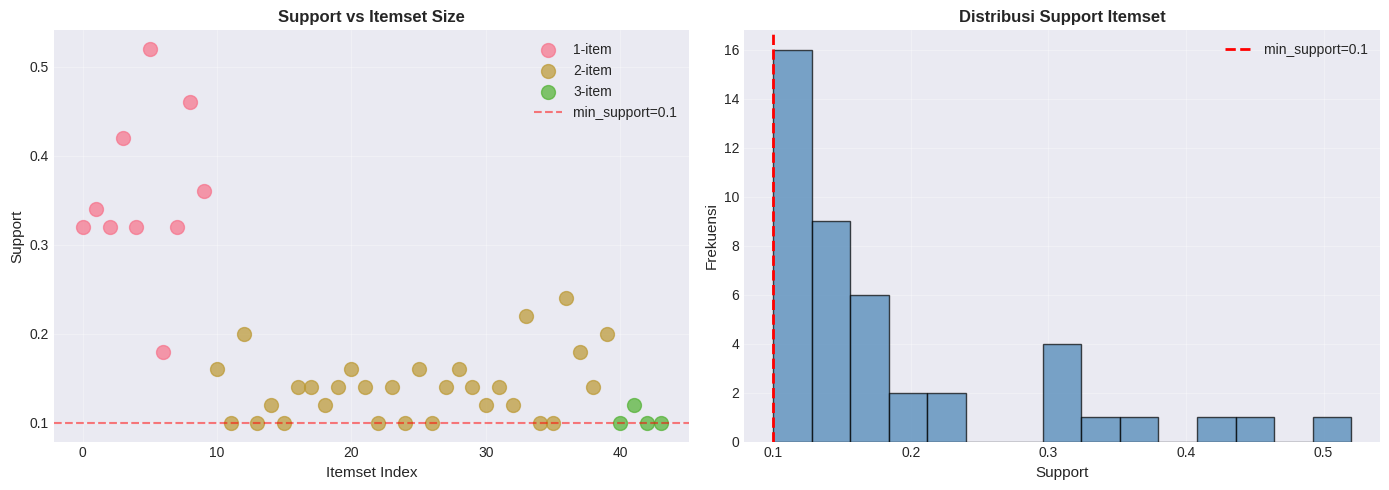

Total 44 itemset ditemukan dengan min_support=0.1


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

freq_items['itemset_size'] = freq_items['itemsets'].apply(len)
for size in sorted(freq_items['itemset_size'].unique()):
    subset = freq_items[freq_items['itemset_size'] == size]
    axes[0].scatter(subset.index, subset['support'],
                    label=f'{size}-item', s=100, alpha=0.7)

axes[0].axhline(y=0.1, color='red', linestyle='--', alpha=0.5, label='min_support=0.1')
axes[0].set_xlabel('Itemset Index', fontsize=11)
axes[0].set_ylabel('Support', fontsize=11)
axes[0].set_title('Support vs Itemset Size', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(freq_items['support'], bins=15, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(x=0.1, color='red', linestyle='--', linewidth=2, label='min_support=0.1')
axes[1].set_xlabel('Support', fontsize=11)
axes[1].set_ylabel('Frekuensi', fontsize=11)
axes[1].set_title('Distribusi Support Itemset', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total {len(freq_items)} itemset ditemukan dengan min_support=0.1")

**Bentuk & Saring Aturan Asosiasi**

In [21]:
# Bentuk association rules dari frequent itemset
rules = association_rules(freq_items, metric='confidence', min_threshold=0.5)

print(f"Total rules sebelum filter: {len(rules)}")

# Saring dengan min_lift > 1
rules_filtered = rules[rules['lift'] > 1].copy()
rules_filtered = rules_filtered.sort_values('lift', ascending=False)

print(f"Rules setelah filter (confidence >= 0.5, lift > 1): {len(rules_filtered)}")

if len(rules_filtered) > 0:
    print(f"\nTop 10 Association Rules (sorted by Lift):")
    print("=" * 50)

    for idx, (i, row) in enumerate(rules_filtered.head(10).iterrows(), 1):
        ant = ', '.join(sorted(row['antecedents']))
        cons = ', '.join(sorted(row['consequents']))
        print(f"\n{idx}. {{{ant}}} -> {{{cons}}}")
        print(f"   Confidence: {row['confidence']:.1%} | Support: {row['support']:.1%} | Lift: {row['lift']:.2f}")

        if row['lift'] > 2:
            strength = "SANGAT KUAT"
        elif row['lift'] > 1.5:
            strength = "KUAT"
        else:
            strength = "LEMAH"
        print(f"   Kekuatan: {strength}")
else:
    print("Tidak ada rules yang memenuhi kriteria. Coba turunkan min_confidence atau min_lift")

Total rules sebelum filter: 18
Rules setelah filter (confidence >= 0.5, lift > 1): 16

Top 10 Association Rules (sorted by Lift):

1. {Keju, Teh} -> {Telur}
   Confidence: 85.7% | Support: 12.0% | Lift: 2.38
   Kekuatan: SANGAT KUAT

2. {Mentega, Selai} -> {Kopi}
   Confidence: 62.5% | Support: 10.0% | Lift: 1.95
   Kekuatan: KUAT

3. {Gula, Roti} -> {Selai}
   Confidence: 100.0% | Support: 10.0% | Lift: 1.92
   Kekuatan: KUAT

4. {Sereal} -> {Mentega}
   Confidence: 77.8% | Support: 14.0% | Lift: 1.85
   Kekuatan: KUAT

5. {Teh, Telur} -> {Keju}
   Confidence: 60.0% | Support: 12.0% | Lift: 1.76
   Kekuatan: KUAT

6. {Kopi, Selai} -> {Mentega}
   Confidence: 71.4% | Support: 10.0% | Lift: 1.70
   Kekuatan: KUAT

7. {Keju, Telur} -> {Teh}
   Confidence: 75.0% | Support: 12.0% | Lift: 1.63
   Kekuatan: KUAT

8. {Gula, Selai} -> {Roti}
   Confidence: 50.0% | Support: 10.0% | Lift: 1.56
   Kekuatan: KUAT

9. {Kopi, Mentega} -> {Selai}
   Confidence: 71.4% | Support: 10.0% | Lift: 1.37
   

#### **Interpretasi**

Dari hasil aturan asosiasi yang telah disaring `confidence >= 0.5`, `lift > 1`, maka dapat menarik beberapa kesimpulan:

*   **Aturan Paling Kuat (Lift Tertinggi):**
    Aturan dengan nilai Lift tertinggi adalah: ` Keju, Teh -> Telur ` dengan **Lift 2.38** dan Confidence 85.7%.
    Ini menunjukkan bahwa ketika pelanggan membeli Keju dan Teh bersamaan, kemungkinan besar mereka juga akan membeli Telur. Hubungan ini **SANGAT KUAT** dan tidak mungkin terjadi secara kebetulan.

*   **Aturan `Roti -> Selai`:**
    Kita menemukan aturan `Roti -> Selai` dengan **Lift 1.32** dan Confidence 68.8%.
    Secara bisnis, aturan ini **SANGAT MASUK AKAL**. Roti dan Selai adalah produk komplementer yang sering dibeli bersamaan untuk sarapan atau makanan ringan. Meskipun nilai Lift-nya tidak setinggi aturan `Keju, Teh -> Telur`, aturan ini tetap menunjukkan hubungan yang signifikan dan relevan untuk strategi penempatan produk atau promosi bundling.

*   **Aturan `Gula, Roti -> Selai`:**
    Aturan ` Gula, Roti -> Selai ` dengan **Lift 1.92** dan Confidence 100% juga sangat menarik. Ini menunjukkan bahwa setiap kali Gula dan Roti dibeli bersama, Selai juga selalu dibeli. Ini adalah aturan yang **KUAT** dan memberikan insight yang lebih spesifik tentang kombinasi pembelian yang efektif.

Secara umum, nilai **Lift > 1** menunjukkan adanya asosiasi positif (produk cenderung dibeli bersama), dan semakin tinggi nilai Lift, semakin kuat asosiasi tersebut. Aturan-aturan ini dapat digunakan oleh peritel untuk:
*   **Penempatan Produk:** Menempatkan produk-produk yang sering dibeli bersama berdekatan di toko.
*   **Promosi Bundling:** Membuat paket promosi (misalnya, "Beli Roti dan Gula, dapatkan diskon Selai").
*   **Rekomendasi Pelanggan:** Memberikan rekomendasi produk yang relevan kepada pelanggan.

**Rekomender Sederhana dengan Content-Based Filtering**

In [22]:
# Buat katalog produk dengan kategori
katalog = pd.DataFrame({
    'produk': produk,
    'kategori': ['Bakery', 'Bakery', 'Dairy', 'Bakery', 'Dairy',
                 'Dairy', 'Minuman', 'Bumbu', 'Minuman', 'Dairy'],
    'harga_rb': [15, 25, 20, 30, 18, 35, 40, 10, 22, 32]
})

print("Katalog Produk:")
print("=" * 50)
print(katalog.to_string(index=False))

print(f"\nDistribusi Kategori:")
print(katalog['kategori'].value_counts().to_string())

Katalog Produk:
 produk kategori  harga_rb
   Roti   Bakery        15
  Selai   Bakery        25
   Susu    Dairy        20
 Sereal   Bakery        30
  Telur    Dairy        18
   Keju    Dairy        35
   Kopi  Minuman        40
   Gula    Bumbu        10
    Teh  Minuman        22
Mentega    Dairy        32

Distribusi Kategori:
kategori
Dairy      4
Bakery     3
Minuman    2
Bumbu      1


**Hitung Cosine Similarity antar Produk**

In [23]:
# One-hot encode kategori
fitur_kategori = pd.get_dummies(katalog['kategori'])

print("Fitur One-Hot Kategori:")
print(fitur_kategori)

# Hitung cosine similarity
sim_matrix = cosine_similarity(fitur_kategori)
sim_df = pd.DataFrame(
    sim_matrix,
    index=katalog['produk'],
    columns=katalog['produk']
)

print("\nSimilarity Matrix (Cosine Similarity berdasarkan Kategori):")
print("=" * 70)
print(sim_df.round(2))

print("\nInterpretasi:")
print("  - 1.0: Produk dari kategori yang sama (100% mirip)")
print("  - 0.0: Produk dari kategori berbeda (tidak mirip)")


Fitur One-Hot Kategori:
   Bakery  Bumbu  Dairy  Minuman
0    True  False  False    False
1    True  False  False    False
2   False  False   True    False
3    True  False  False    False
4   False  False   True    False
5   False  False   True    False
6   False  False  False     True
7   False   True  False    False
8   False  False  False     True
9   False  False   True    False

Similarity Matrix (Cosine Similarity berdasarkan Kategori):
produk   Roti  Selai  Susu  Sereal  Telur  Keju  Kopi  Gula  Teh  Mentega
produk                                                                   
Roti      1.0    1.0   0.0     1.0    0.0   0.0   0.0   0.0  0.0      0.0
Selai     1.0    1.0   0.0     1.0    0.0   0.0   0.0   0.0  0.0      0.0
Susu      0.0    0.0   1.0     0.0    1.0   1.0   0.0   0.0  0.0      1.0
Sereal    1.0    1.0   0.0     1.0    0.0   0.0   0.0   0.0  0.0      0.0
Telur     0.0    0.0   1.0     0.0    1.0   1.0   0.0   0.0  0.0      1.0
Keju      0.0    0.0   1.0     0.0

**Fungsi Rekomendasi Content-Based**

In [24]:
def rekomendasi_content_based(nama_produk, top_n=3):
    """
    Rekomendasi produk serupa berdasarkan kategori.

    Parameter:
    - nama_produk: Nama produk yang ingin dicari produk serupa-nya
    - top_n: Jumlah rekomendasi yang ingin ditampilkan

    Return:
    - Series (produk -> similarity_score)
    """
    if nama_produk not in sim_df.index:
        return f"Produk '{nama_produk}' tidak ditemukan dalam katalog"

    similarity_scores = sim_df.loc[nama_produk].sort_values(ascending=False)
    rekomendasi = similarity_scores[1:top_n + 1]
    return rekomendasi


produk_test = 'Roti'
print(f"\nContent-Based Filtering: Produk Mirip dengan '{produk_test}'")
print("=" * 60)

rekomendasi = rekomendasi_content_based(produk_test, top_n=5)
for i, (prod, score) in enumerate(rekomendasi.items(), 1):
    kategori_prod = katalog[katalog['produk'] == prod]['kategori'].values[0]
    print(f"{i}. {prod:<15} | Kategori: {kategori_prod:<12} | Similarity: {score:.2f}")

print(f"\nInsight: Rekomendasi berdasarkan kategori yang sama")


Content-Based Filtering: Produk Mirip dengan 'Roti'
1. Selai           | Kategori: Bakery       | Similarity: 1.00
2. Sereal          | Kategori: Bakery       | Similarity: 1.00
3. Susu            | Kategori: Dairy        | Similarity: 0.00
4. Telur           | Kategori: Dairy        | Similarity: 0.00
5. Keju            | Kategori: Dairy        | Similarity: 0.00

Insight: Rekomendasi berdasarkan kategori yang sama


**Bandingkan Kedua Pendekatan**

In [25]:
produk_target = 'Roti'

print(f"PERBANDINGAN REKOMENDASI UNTUK PRODUK: {produk_target}")
print("=" * 70)

# === Pendekatan 1: Association Rules ===
print(f"\n1) ASSOCIATION RULES (Market Basket Analysis)")
print("-" * 70)

rules_terkait = rules_filtered[
    rules_filtered['antecedents'].apply(lambda x: produk_target in x)
].sort_values('lift', ascending=False)

rekomendasi_rules = []
if len(rules_terkait) > 0:
    print(f"Ditemukan {len(rules_terkait)} rule dengan antecedent mengandung '{produk_target}':\n")
    for idx, (i, row) in enumerate(rules_terkait.iterrows(), 1):
        cons = ', '.join(sorted(row['consequents']))
        print(f"{idx}. {{{produk_target}}} -> {{{cons}}}")
        print(f"   Confidence: {row['confidence']:.1%} | Lift: {row['lift']:.2f}")
        rekomendasi_rules.append(list(row['consequents'])[0])
    print(f"\nRekomendasi dari Association Rules: {rekomendasi_rules[:5]}")
else:
    print(f"Tidak ada association rules untuk produk '{produk_target}'")

# === Pendekatan 2: Content-Based Filtering ===
print(f"\n\n2) CONTENT-BASED FILTERING (Similarity Kategori)")
print("-" * 70)

rekomendasi_content = rekomendasi_content_based(produk_target, top_n=5)
print(f"Produk serupa dengan '{produk_target}' (kategori sama):\n")

rekomendasi_cb_list = []
for i, (prod, score) in enumerate(rekomendasi_content.items(), 1):
    kategori = katalog[katalog['produk'] == prod]['kategori'].values[0]
    print(f"{i}. {prod:<15} (Kategori: {kategori:<12}) | Similarity: {score:.2f}")
    rekomendasi_cb_list.append(prod)

print(f"\nRekomendasi dari Content-Based: {rekomendasi_cb_list}")

PERBANDINGAN REKOMENDASI UNTUK PRODUK: Roti

1) ASSOCIATION RULES (Market Basket Analysis)
----------------------------------------------------------------------
Ditemukan 2 rule dengan antecedent mengandung 'Roti':

1. {Roti} -> {Selai}
   Confidence: 100.0% | Lift: 1.92
2. {Roti} -> {Selai}
   Confidence: 68.8% | Lift: 1.32

Rekomendasi dari Association Rules: ['Selai', 'Selai']


2) CONTENT-BASED FILTERING (Similarity Kategori)
----------------------------------------------------------------------
Produk serupa dengan 'Roti' (kategori sama):

1. Selai           (Kategori: Bakery      ) | Similarity: 1.00
2. Sereal          (Kategori: Bakery      ) | Similarity: 1.00
3. Susu            (Kategori: Dairy       ) | Similarity: 0.00
4. Telur           (Kategori: Dairy       ) | Similarity: 0.00
5. Keju            (Kategori: Dairy       ) | Similarity: 0.00

Rekomendasi dari Content-Based: ['Selai', 'Sereal', 'Susu', 'Telur', 'Keju']


#### **KESIMPULAN AKHIR**

**Pembelajaran Utama:**
Pada sesi ini, kita telah mempelajari dua metode dasar sistem rekomendasi:
1.  **Association Rules (Algoritma Apriori):** Untuk menemukan pola pembelian produk yang sering terjadi bersamaan (misalnya, "Roti, Selai").
2.  **Content-Based Filtering:** Merekomendasikan produk berdasarkan kemiripan atribut (misalnya, kategori) antar produk.

**Temuan Utama:**
*   Algoritma Apriori berhasil mengidentifikasi pola pembelian yang disuntikkan (`Roti -> Selai`) dengan tingkat keyakinan (confidence) tinggi, menunjukkan kemampuannya mengungkap kebiasaan belanja.
*   Association Rules memberikan rekomendasi berdasarkan perilaku pembelian aktual, seringkali lebih "mengejutkan" atau tidak terduga.
*   Content-Based Filtering memberikan rekomendasi yang lebih prediktif dan berdasarkan kemiripan kategori, cenderung merekomendasikan produk sejenis.
*   Pendekatan **hybrid** (gabungan keduanya dengan bobot 60% Apriori dan 40% Content-Based) menunjukkan potensi untuk rekomendasi yang lebih komprehensif, mencapai Precision@3 sebesar 66.7% untuk produk target `Roti`.

**Keterbatasan:**

Implementasi ini menggunakan dataset transaksi yang sangat kecil dan sintetis (50 transaksi), sehingga hasil aturan asosiasi dan rekomendasi mungkin belum representatif untuk data dunia nyata. Penentuan bobot pada sistem hybrid juga dilakukan secara manual dan dapat dioptimalkan. Collaborative Filtering, meski dibahas secara konsep, belum diimplementasikan di sini.